# Evaluación 2 - ID 1001371283
**Programación Científica 2026-1** · Universidad Nacional de Colombia

Este notebook contiene la solución completa para los 4 entregables de la rúbrica:
1. Capa Fourier y energía media.
2. Entrenamiento y reconstrucción (3 regímenes, 2 inicializaciones).
3. Comparación de inicializaciones y régimen difícil.
4. Compresión y umbral del 95%.

In [228]:
# =============================================
# BLOQUE 0: IMPORTS Y CARGA DE DATOS
# =============================================

# Librerías estándar para números y gráficas
import numpy as np
import matplotlib.pyplot as plt

# JAX para el entrenamiento de la red neuronal
import jax
import jax.numpy as jnp
from jax import grad, jit

# Suprimir warnings para que la salida se vea limpia
import warnings
warnings.filterwarnings('ignore')

# Cargar el archivo de datos generado específicamente para nuestro ID
data = np.load('datos_1283.npz')

# Extraer los arrays del archivo
X = data['X']        # (24, 256): 24 señales, cada una de 256 puntos
y = data['y']        # (24,): etiquetas de régimen (0, 1, 2)
t = data['t']        # (256,): vector de tiempo físico (0 a 1)
meta = data['meta']  # (3,): parámetros del medio (no los usamos)

# Mostrar las dimensiones para confirmar que se cargaron bien
print("Datos cargados correctamente:")
print(f"  Señales X: {X.shape}")
print(f"  Etiquetas y: {y.shape}")
print(f"  Tiempo t: {t.shape}")

Datos cargados correctamente:
  Señales X: (24, 256)
  Etiquetas y: (24,)
  Tiempo t: (256,)


In [229]:
# =============================================
# BLOQUE 0: PARÁMETROS DEL PROBLEMA
# =============================================

# N: longitud de cada señal (dimensión de entrada y salida)
N = 256

# K: número de frecuencias que usamos en la capa Fourier.
# La capa tendrá 2K neuronas (K senos + K cosenos).
# Nota: Entre mayor sea k mejor da el entrenamiento (2*k es el numero de neuronas)
K = 10

# Parámetros de entrenamiento
LEARNING_RATE = 0.05    # Tamaño del paso para el descenso por gradiente
EPOCHS = 3000       # Número de iteraciones 
# LAMBDA: Factor de regularización L2. Controla el equilibrio entre el error de 
# reconstrucción y la magnitud de los pesos. Un valor muy bajo (1e-5 o 0) provoca 
# sobreajuste (reconstrucción perfecta para ambas). Un valor muy alto (1e-2) 
# provoca subajuste (ambas reconstrucciones son malas). El valor intermedio 
# (1e-4) permite que Fourier destaque sobre la inicialización aleatoria
LAMBDA = 1e-4         # Regularización 

print(f"Parámetros definidos:")
print(f"  N = {N}, K = {K}")
print(f"  Learning Rate = {LEARNING_RATE}, Épocas = {EPOCHS}, L2 = {LAMBDA}")

Parámetros definidos:
  N = 256, K = 10
  Learning Rate = 0.05, Épocas = 3000, L2 = 0.0001


## 1. Capa Fourier

Se construye la matriz $W_1$ de tamaño $(2K \times N)$ con senos y cosenos para las frecuencias $k=1,\dots,K$. Se usa el índice discreto $n = 0,\dots,N-1$ para que coincida con la definición de la DFT de NumPy.

Matriz W_fourier creada con forma: (20, 256)
Error relativo vs FFT de NumPy: 7.26e-16 (debe ser ~1e-15)


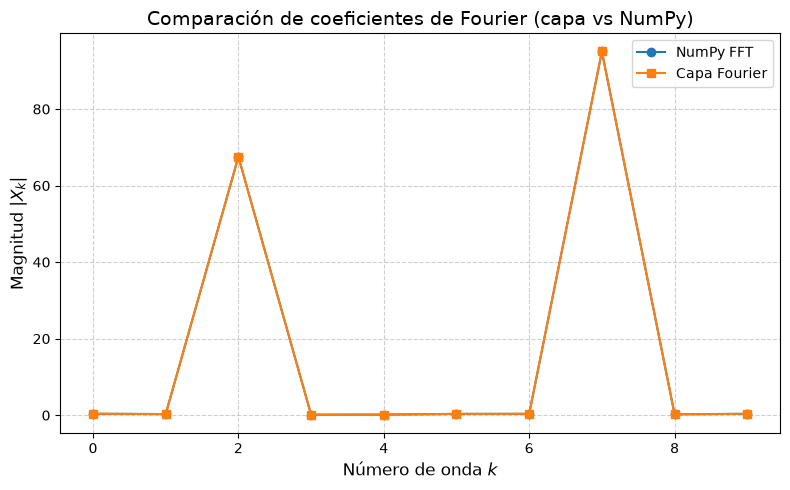

Energía media del dataset (valor cuadrático medio): 0.838


In [230]:
# =============================================
# BLOQUE 1: CAPA FOURIER Y VERIFICACIÓN
# =============================================

def construir_capa_fourier(N, K):
    """
    Construye la matriz W de tamaño (2K, N).
    Para k = 1..K:
      - Fila par (2k-2): coseno
      - Fila impar (2k-1): seno
    Usa n = 0, 1, ..., N-1 (índices discretos) para coincidir con np.fft.
    """
    # Crear los índices de tiempo discreto (0, 1, ..., N-1)
    n = np.arange(N)
    # Inicializar la matriz con ceros
    W = np.zeros((2 * K, N))
    
    # Llenar cada par de filas
    for k in range(1, K + 1):
        # Fila para el coseno: cos(2*pi * k * n / N)
        W[2 * (k - 1), :] = np.cos(2 * np.pi * k * n / N)
        # Fila para el seno: sin(2*pi * k * n / N)
        W[2 * (k - 1) + 1, :] = np.sin(2 * np.pi * k * n / N)
    return W

# Construir la matriz
W_fourier = construir_capa_fourier(N, K)
print(f"Matriz W_fourier creada con forma: {W_fourier.shape}")

# =============================================
# 2.1 VERIFICACIÓN: comparar con np.fft.fft
# =============================================

# Tomamos la primera señal del dataset como prueba
x_test = X[0]

# Proyectar la señal en la capa Fourier: z = W @ x
z = W_fourier @ x_test

# Separar coeficientes de cosenos (pares) y senos (impares)
cos_coef = z[0::2]  # a_k
sen_coef = z[1::2]  # b_k

# Construir el coeficiente complejo según la convención de la FFT:
# X[k] = a_k - i * b_k  (para k=1..K)
coef_complejo = cos_coef - 1j * sen_coef

# Calcular la FFT completa con NumPy y tomar solo k=1..K
fft_ref = np.fft.fft(x_test)[1:K+1]

# Error relativo entre las magnitudes de los coeficientes
error_fft = np.linalg.norm(np.abs(coef_complejo) - np.abs(fft_ref)) / np.linalg.norm(np.abs(fft_ref))
print(f"Error relativo vs FFT de NumPy: {error_fft:.2e} (debe ser ~1e-15)")

# Gráfica para comparar visualmente las magnitudes
plt.figure(figsize=(8, 5))
plt.plot(np.abs(fft_ref), 'o-', label='NumPy FFT', markersize=6)
plt.plot(np.abs(coef_complejo), 's-', label='Capa Fourier', markersize=6)
plt.xlabel(r'Número de onda $k$', fontsize=12)
plt.ylabel(r'Magnitud $|X_k|$', fontsize=12)
plt.title('Comparación de coeficientes de Fourier (capa vs NumPy)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# =============================================
# 2.2 ENERGÍA MEDIA DEL DATASET (requerido en rúbrica)
# =============================================

energia_media = (X**2).mean()
print(f"Energía media del dataset (valor cuadrático medio): {energia_media:.3f}")

## 2. Señales por régimen

El dataset contiene 8 señales por régimen:
- Régimen 0: baja frecuencia
- Régimen 1: media frecuencia (régimen difícil)
- Régimen 2: alta frecuencia

Se selecciona la primera señal de cada régimen para los experimentos.

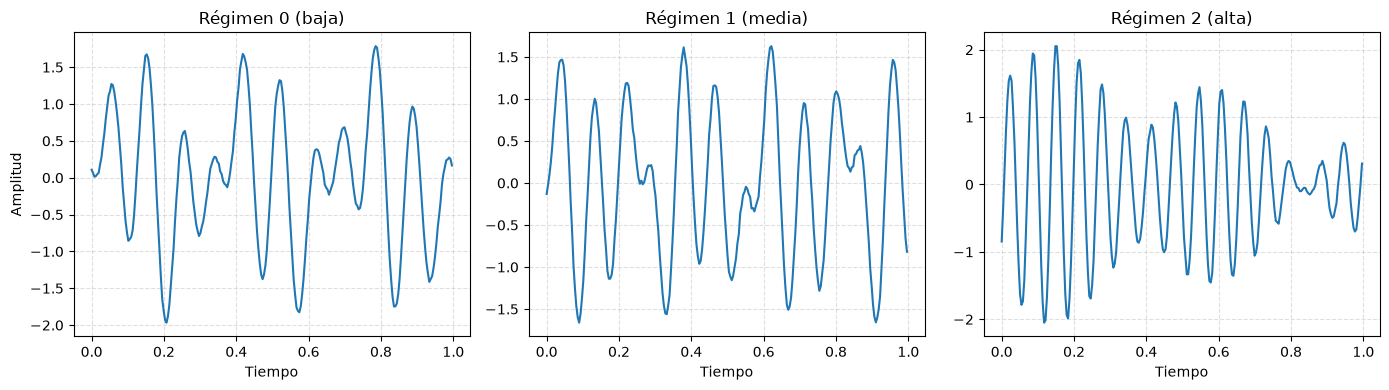

In [231]:
# =============================================
# BLOQUE 3: SEPARACIÓN POR RÉGIMENES
# =============================================

# Cada régimen tiene 8 señales. Separarlas por etiqueta.
X0 = X[y == 0]  # Régimen 0: baja frecuencia
X1 = X[y == 1]  # Régimen 1: media frecuencia (el "difícil" según enunciado)
X2 = X[y == 2]  # Régimen 2: alta frecuencia

# Tomamos la primera señal de cada régimen para los experimentos
x_reg0 = X0[0]
x_reg1 = X1[0]
x_reg2 = X2[0]

# Guardar en listas para iterar fácilmente
señales = [x_reg0, x_reg1, x_reg2]
nombres = ['Régimen 0 (baja)', 'Régimen 1 (media)', 'Régimen 2 (alta)']

# Graficar las tres señales para ver sus diferencias
plt.figure(figsize=(14, 4))
for i, (x, nombre) in enumerate(zip(señales, nombres)):
    plt.subplot(1, 3, i+1)
    plt.plot(t, x)
    plt.title(nombre, fontsize=12)
    plt.xlabel('Tiempo')
    if i == 0:
        plt.ylabel('Amplitud')
    plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 3. Reconstrucción lineal directa

Usando solo la capa Fourier (sin entrenar), reconstruimos la señal para ver el efecto de truncar frecuencias y omitir el componente DC. Esto explica por qué la red neuronal debe aprender un sesgo.

Error relativo de reconstrucción lineal: 0.7302
Energía en frecuencias > k=30: 0.09%


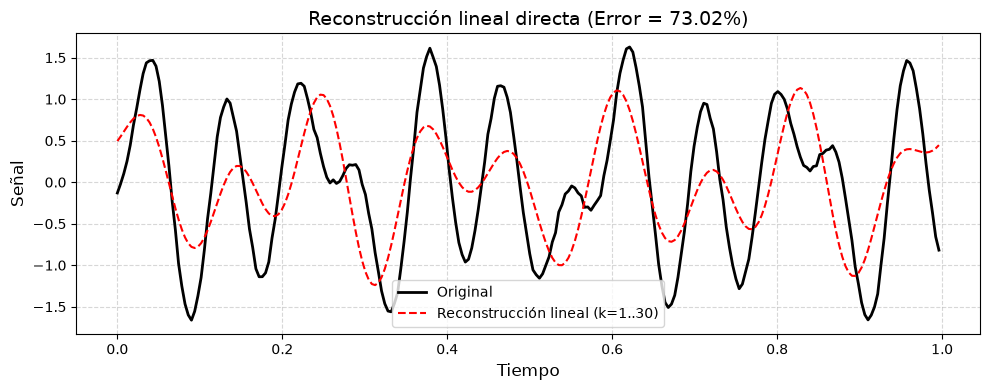

In [232]:
# =============================================
# 3. RECONSTRUCCIÓN LINEAL CON CAPA FOURIER
# =============================================

x_prueba = x_reg1  # Usamos el régimen 1 como ejemplo

z = W_fourier @ x_prueba
# Reconstrucción con factor 2/N (porque la base no está normalizada)
x_hat_lineal = (2.0 / N) * (W_fourier.T @ z)

error_lineal = np.linalg.norm(x_hat_lineal - x_prueba) / np.linalg.norm(x_prueba)
print(f"Error relativo de reconstrucción lineal: {error_lineal:.4f}")

# Análisis espectral para entender el error
fft_total = np.fft.fft(x_prueba)
energia_total = np.sum(np.abs(fft_total)**2)
energia_truncada = np.sum(np.abs(fft_total[31:N//2])**2)  # frecuencias > 30
print(f"Energía en frecuencias > k=30: {100 * energia_truncada / energia_total:.2f}%")

plt.figure(figsize=(10, 4))
plt.plot(t, x_prueba, 'k-', label='Original', linewidth=2)
plt.plot(t, x_hat_lineal, 'r--', label='Reconstrucción lineal (k=1..30)', linewidth=1.5)
plt.xlabel('Tiempo', fontsize=12)
plt.ylabel('Señal', fontsize=12)
plt.title(f'Reconstrucción lineal directa (Error = {error_lineal:.2%})', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Arquitectura de la red

La red tiene dos capas:
1. Capa lineal $W_1$: $256 \to 60$ seguida de $\tanh$.
2. Capa lineal $W_2$: $60 \to 256$ (reconstrucción).

Se inicializa de dos formas:
- **Fourier:** $W_1$ fija como la matriz de Fourier, $W_2$ aleatoria.
- **Aleatoria:** $W_1$ y $W_2$ aleatorias.

La pérdida es el error cuadrático medio (MSE) entre la señal original y la reconstruida.

In [233]:
# =============================================
# BLOQUE 4: RED NEURONAL EN JAX
# =============================================

def red(W1, W2, x):
    """
    Arquitectura de la red:
    x (256) -> W1 (2K x 256) -> tanh -> W2 (256 x 2K) -> x_hat (256)
    """
    # Capa oculta: combinación lineal seguida de tangente hiperbólica
    h = jnp.tanh(W1 @ x)
    # Capa de salida: lineal, reconstruye la señal
    x_hat = W2 @ h
    return x_hat

def loss_fn(W1, W2, x, objetivo, lambd):
    """
    Función de pérdida = Error cuadrático medio + Regularización L2.
    La regularización penaliza los pesos grandes para evitar sobreajuste.
    """
    # Reconstruir la señal
    x_hat = red(W1, W2, x)
    
    # Error cuadrático medio (MSE)
    mse = jnp.mean((x_hat - objetivo) ** 2)
    
    # Término de regularización L2 (suma de los cuadrados de todos los pesos)
    reg = lambd * (jnp.sum(W1 ** 2) + jnp.sum(W2 ** 2))
    
    # Pérdida total
    return mse + reg

# Función que calcula los gradientes de la pérdida con respecto a W1 y W2
# argnums=(0,1) indica que queremos derivar respecto a W1 y W2
grad_loss = grad(loss_fn, argnums=(0, 1))

## 5. Entrenamiento

Se entrena la red para las 3 señales de prueba (una por régimen), con ambas inicializaciones (Fourier y aleatoria). Se guardan las pérdidas y errores cada 50 iteraciones.

In [234]:
# =============================================
# BLOQUE 5: ENTRENAMIENTO E INICIALIZACIONES
# =============================================

def entrenar(W1_init, W2_init, x, lr, steps, lambd, log_every=50):
    """
    Entrena la red con descenso por gradiente.
    Guarda la pérdida y el error relativo cada `log_every` iteraciones.
    """
    # Copiar los pesos iniciales para no mutar los originales
    W1 = W1_init
    W2 = W2_init
    
    # Listas para almacenar el historial
    losses = []
    errors = []
    
    # Bucle de entrenamiento
    for i in range(steps):
        # Calcular gradientes
        g1, g2 = grad_loss(W1, W2, x, x, lambd)
        
        # Actualizar pesos (descenso por gradiente)
        W1 = W1 - lr * g1
        W2 = W2 - lr * g2
        
        # Guardar métricas cada 'log_every' pasos
        if i % log_every == 0:
            # Obtener la reconstrucción actual
            x_hat = red(W1, W2, x)
            # Calcular pérdida total (MSE + reg) para monitoreo
            loss = float(loss_fn(W1, W2, x, x, lambd))
            # Calcular error relativo: ||x_hat - x|| / ||x||
            error = float(jnp.linalg.norm(x_hat - x) / jnp.linalg.norm(x))
            
            losses.append(loss)
            errors.append(error)
    
    # Reconstrucción final (convertida a numpy para graficar)
    x_hat_final = np.array(red(W1, W2, x))
    return losses, errors, x_hat_final

# =============================================
# 5.1 INICIALIZACIONES
# =============================================

# --- Inicialización Fourier ---
# W1 = matriz de Fourier (fija al inicio, pero se entrenará)
W1_fourier = jnp.array(W_fourier)
# W2 = pesos aleatorios pequeños (normal, std=0.1)
W2_fourier = jnp.array(np.random.normal(0, 0.1, (N, 2 * K)))

# --- Inicialización Aleatoria ---
# W1 = pesos aleatorios con std=1.0 (para darle variedad)
W1_alea = jnp.array(np.random.normal(0, 1.0, (2 * K, N)))
# W2 = pesos aleatorios pequeños
W2_alea = jnp.array(np.random.normal(0, 0.1, (N, 2 * K)))

print("Inicializaciones listas:")
print(f"  W1 Fourier: {W1_fourier.shape}, W2 Fourier: {W2_fourier.shape}")
print(f"  W1 Aleatoria: {W1_alea.shape}, W2 Aleatoria: {W2_alea.shape}")

Inicializaciones listas:
  W1 Fourier: (20, 256), W2 Fourier: (256, 20)
  W1 Aleatoria: (20, 256), W2 Aleatoria: (256, 20)


In [235]:
# =============================================
# ENTRENAMIENTO
# =============================================

# Diccionario para guardar todos los resultados
# Clave: (índice_régimen, 'fourier' o 'aleatoria')
# Valor: (lista_pérdidas, lista_errores, reconstrucción_final)
resultados = {}

# Bucle sobre los 3 regímenes
for idx, (x, nombre) in enumerate(zip(señales, nombres)):
    # Convertir la señal numpy a un array de JAX (para GPU/TPU)
    x_jax = jnp.array(x)
    
    print(f"\n--- Entrenando {nombre} ---")
    
    # --- Entrenar con inicialización Fourier ---
    print("  Inicialización Fourier...")
    losses_f, errors_f, x_hat_f = entrenar(
        W1_fourier, W2_fourier, x_jax, 
        lr=LEARNING_RATE, steps=EPOCHS, lambd=LAMBDA
    )
    resultados[(idx, 'fourier')] = (losses_f, errors_f, x_hat_f)
    
    # --- Entrenar con inicialización Aleatoria ---
    print("  Inicialización Aleatoria...")
    losses_a, errors_a, x_hat_a = entrenar(
        W1_alea, W2_alea, x_jax,
        lr=LEARNING_RATE, steps=EPOCHS, lambd=LAMBDA
    )
    resultados[(idx, 'aleatoria')] = (losses_a, errors_a, x_hat_a)

print("\n✅ Entrenamiento completado para todos los regímenes.")


--- Entrenando Régimen 0 (baja) ---
  Inicialización Fourier...
  Inicialización Aleatoria...

--- Entrenando Régimen 1 (media) ---
  Inicialización Fourier...
  Inicialización Aleatoria...

--- Entrenando Régimen 2 (alta) ---
  Inicialización Fourier...
  Inicialización Aleatoria...

✅ Entrenamiento completado para todos los regímenes.


## 6. Reconstrucción final

Para cada régimen, se muestra la señal original junto a las reconstrucciones obtenidas con ambas inicializaciones.

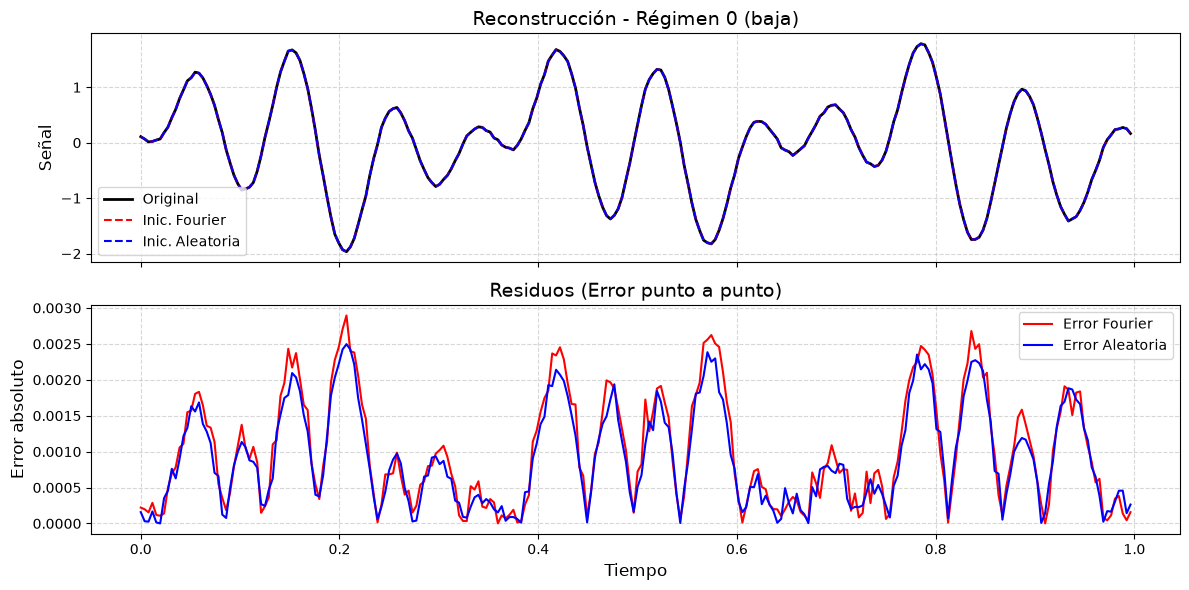

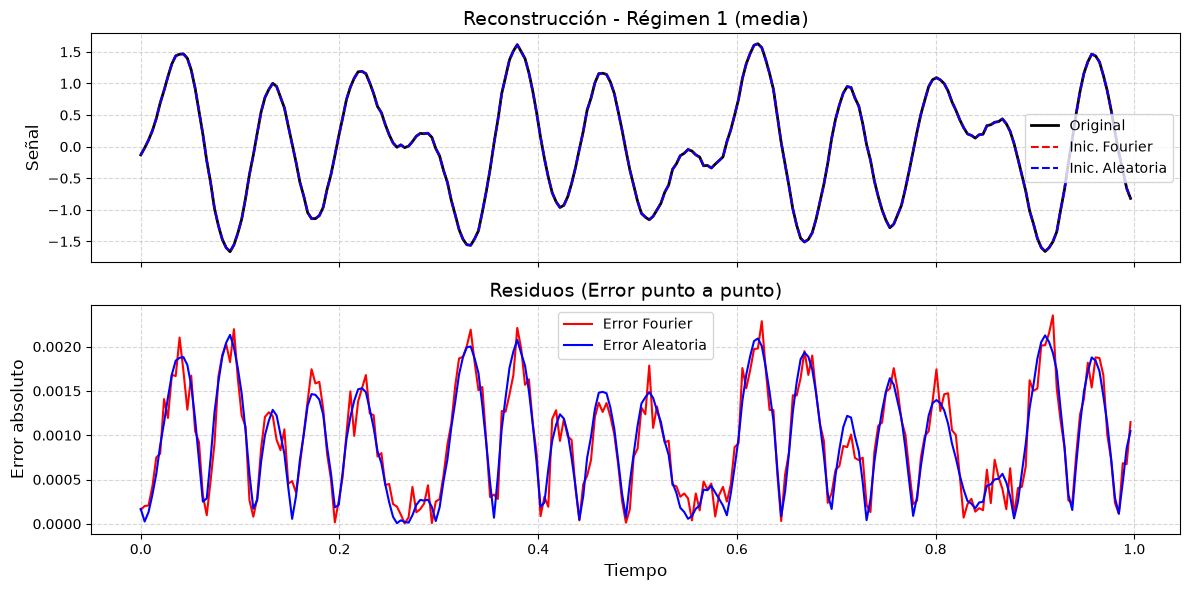

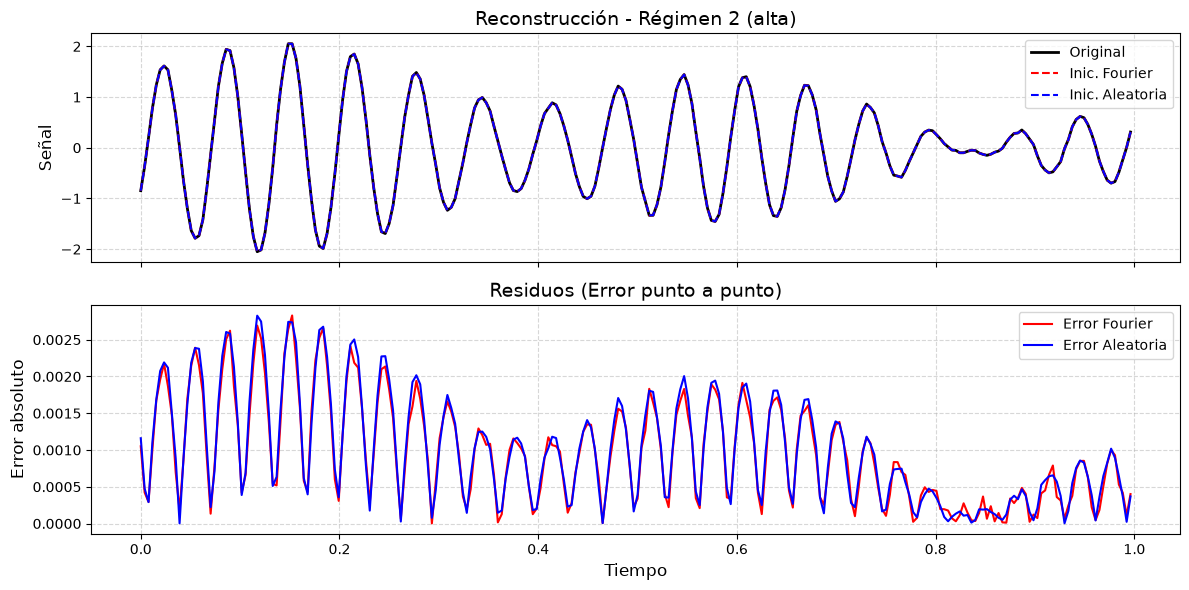

In [236]:
# =============================================
# BLOQUE 6: GRÁFICAS DE RECONSTRUCCIÓN Y RESIDUOS
# =============================================

for idx, nombre in enumerate(nombres):
    # Extraer los resultados del diccionario
    _, _, x_hat_f = resultados[(idx, 'fourier')]
    _, _, x_hat_a = resultados[(idx, 'aleatoria')]
    x_orig = señales[idx]
    
    # Calcular los residuos (errores absolutos en cada punto)
    residuo_f = np.abs(x_orig - x_hat_f)
    residuo_a = np.abs(x_orig - x_hat_a)
    
    # Crear figura con 2 filas (reconstrucción arriba, residuo abajo)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    
    # --- Gráfica superior: Reconstrucción ---
    ax1.plot(t, x_orig, 'k-', label='Original', linewidth=2)
    ax1.plot(t, x_hat_f, 'r--', label='Inic. Fourier', linewidth=1.5)
    ax1.plot(t, x_hat_a, 'b--', label='Inic. Aleatoria', linewidth=1.5)
    ax1.set_ylabel('Señal', fontsize=12)
    ax1.set_title(f'Reconstrucción - {nombre}', fontsize=14)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # --- Gráfica inferior: Residuo (diferencia absoluta) ---
    # Usamos escala lineal para los residuos (porque son positivos y pueden ser cero)
    ax2.plot(t, residuo_f, 'r-', label='Error Fourier', linewidth=1.5)
    ax2.plot(t, residuo_a, 'b-', label='Error Aleatoria', linewidth=1.5)
    ax2.set_xlabel('Tiempo', fontsize=12)
    ax2.set_ylabel('Error absoluto', fontsize=12)
    ax2.set_title('Residuos (Error punto a punto)', fontsize=14)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

## 7. Comparación de inicializaciones

Se comparan las curvas de pérdida y error relativo para ambas inicializaciones. Se mide el número de iteraciones necesarias para que el error relativo baje de 0.1. El régimen 1 (media frecuencia) es el régimen difícil según el enunciado.

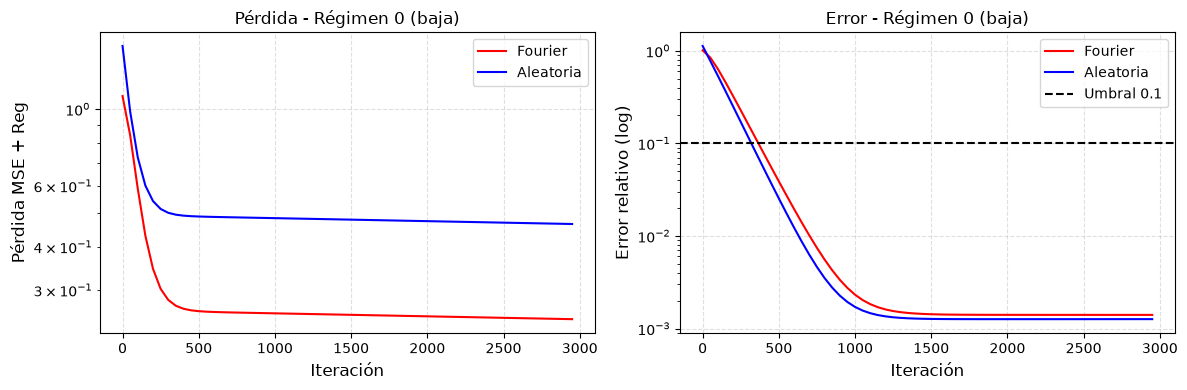

Régimen 0 (baja): Fourier -> 400 iters, Aleatoria -> 350 iters


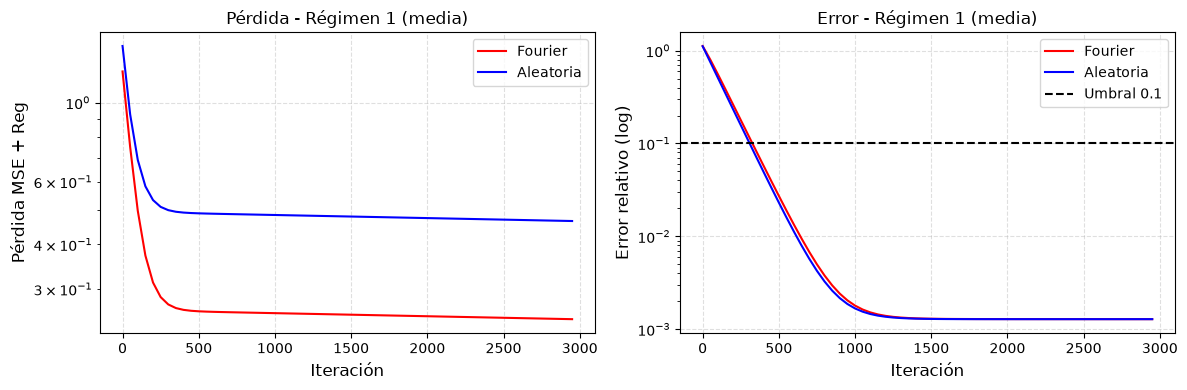

Régimen 1 (media): Fourier -> 350 iters, Aleatoria -> 350 iters


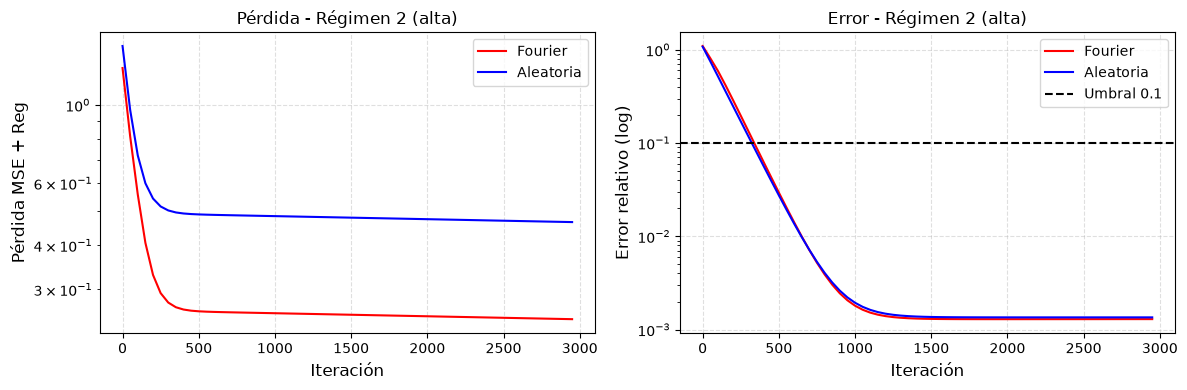

Régimen 2 (alta): Fourier -> 350 iters, Aleatoria -> 350 iters

--- Análisis del régimen difícil (Régimen 1) ---


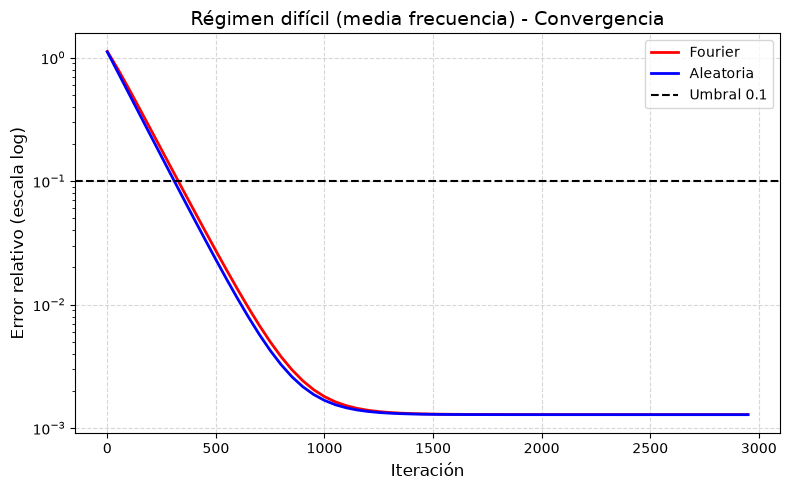

In [237]:
# =============================================
# BLOQUE 7: COMPARACIÓN DE INICIALIZACIONES (CON ESCALA LOG)
# =============================================

# Eje X para las gráficas: iteraciones en las que guardamos (cada 50)
iter_plot = np.arange(0, EPOCHS, 50)

# --- 8.1 Curvas de pérdida y error para cada régimen ---
for idx, nombre in enumerate(nombres):
    losses_f, errors_f, _ = resultados[(idx, 'fourier')]
    losses_a, errors_a, _ = resultados[(idx, 'aleatoria')]
    
    plt.figure(figsize=(12, 4))
    
    # Subplot 1: Pérdida (escala logarítmica)
    plt.subplot(1, 2, 1)
    plt.semilogy(iter_plot, losses_f, 'r-', label='Fourier')
    plt.semilogy(iter_plot, losses_a, 'b-', label='Aleatoria')
    plt.xlabel('Iteración', fontsize=12)
    plt.ylabel('Pérdida MSE + Reg', fontsize=12)
    plt.title(f'Pérdida - {nombre}', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)
    
    # Subplot 2: Error relativo (TAMBIÉN en escala logarítmica para ver las colas)
    plt.subplot(1, 2, 2)
    plt.semilogy(iter_plot, errors_f, 'r-', label='Fourier')  # <--- CAMBIADO a semilogy
    plt.semilogy(iter_plot, errors_a, 'b-', label='Aleatoria') # <--- CAMBIADO a semilogy
    plt.axhline(y=0.1, color='k', linestyle='--', label='Umbral 0.1')
    plt.xlabel('Iteración', fontsize=12)
    plt.ylabel('Error relativo (log)', fontsize=12)  # Añadí "(log)" para claridad
    plt.title(f'Error - {nombre}', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()
    
    # --- Medición de iteraciones para error < 0.1 ---
    idx_f = np.argmax(np.array(errors_f) < 0.1) if any(np.array(errors_f) < 0.1) else -1
    idx_a = np.argmax(np.array(errors_a) < 0.1) if any(np.array(errors_a) < 0.1) else -1
    it_f = iter_plot[idx_f] if idx_f != -1 else 'Nunca'
    it_a = iter_plot[idx_a] if idx_a != -1 else 'Nunca'
    print(f"{nombre}: Fourier -> {it_f} iters, Aleatoria -> {it_a} iters")

# --- 8.2 Análisis especial del Régimen 1 (el "difícil") ---
print("\n--- Análisis del régimen difícil (Régimen 1) ---")
idx_dificil = 1
_, errors_f, _ = resultados[(idx_dificil, 'fourier')]
_, errors_a, _ = resultados[(idx_dificil, 'aleatoria')]

plt.figure(figsize=(8, 5))
plt.semilogy(iter_plot, errors_f, 'r-', linewidth=2, label='Fourier')
plt.semilogy(iter_plot, errors_a, 'b-', linewidth=2, label='Aleatoria')
plt.axhline(y=0.1, color='k', linestyle='--', label='Umbral 0.1')
plt.xlabel('Iteración', fontsize=12)
plt.ylabel('Error relativo (escala log)', fontsize=12)
plt.title('Régimen difícil (media frecuencia) - Convergencia', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 8. Compresión

Se toman los coeficientes de Fourier de la señal del régimen 1, se ordenan por magnitud y se reconstruye la señal conservando solo los $k$ coeficientes más grandes. Se busca el número mínimo de coeficientes para alcanzar el 95% de la energía total.

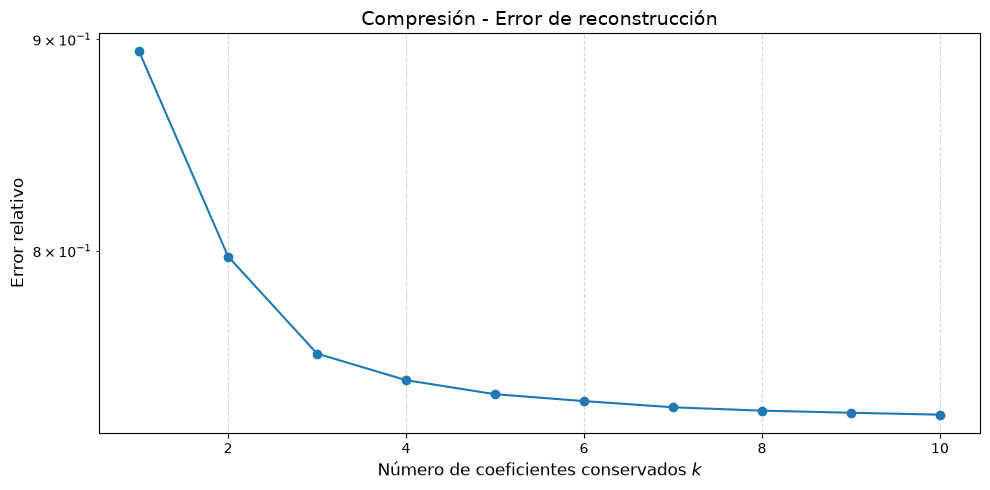

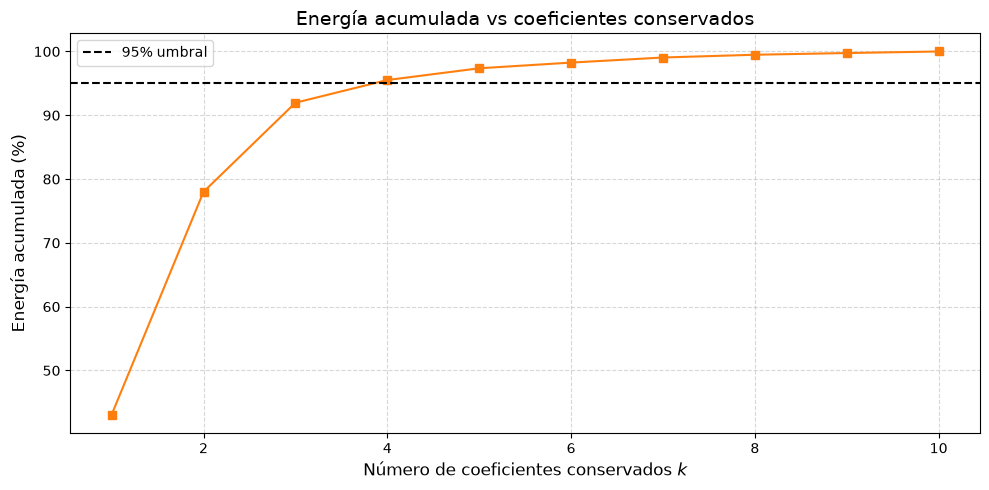

Energía total: 11700.614
Umbral 95%: 11115.583
Coeficientes necesarios para alcanzar el 95% de energía: 4
Energía acumulada con 4 coeficientes: 11177.207 (95.5%)


In [238]:
# =============================================
# BLOQUE 8: COMPRESIÓN
# =============================================

# Usamos la primera señal del régimen 1 para el análisis de compresión
x_comp = x_reg1

# Obtener coeficientes complejos (k=1..K) usando la capa Fourier
z_comp = W_fourier @ x_comp
cos_c = z_comp[0::2]
sen_c = z_comp[1::2]
coef_c = cos_c - 1j * sen_c  # Coeficientes complejos

# Calcular magnitudes y ordenar de mayor a menor
magnitudes = np.abs(coef_c)
idx_sort = np.argsort(magnitudes)[::-1]  # Índices ordenados descendentemente

# Energía total (suma de los cuadrados de las magnitudes)
energia_total = np.sum(magnitudes ** 2)
umbral_95 = 0.95 * energia_total  # Umbral del 95%

# Listas para almacenar resultados
ks = np.arange(1, K + 1)  # Probamos desde 1 hasta K coeficientes
errores = []
energias_acum = []

# Bucle para probar cada cantidad de coeficientes
for k in ks:
    # Crear un arreglo de coeficientes complejos lleno de ceros
    coef_k = np.zeros(K, dtype=complex)
    # Poner los k coeficientes más grandes en sus posiciones originales
    coef_k[idx_sort[:k]] = coef_c[idx_sort[:k]]
    
    # Convertir de vuelta a coeficientes reales (cosenos y senos)
    # Sabemos que: coef_complejo = cos - i*sen
    # -> cos = real(coef), sen = -imag(coef)
    coef_real = np.zeros(2 * K)
    for i in range(K):
        coef_real[2 * i] = np.real(coef_k[i])       # coseno
        coef_real[2 * i + 1] = -np.imag(coef_k[i])  # seno
    
    # Reconstruir la señal linealmente (sin red neuronal)
    # Usamos el factor 2/N porque la base no está normalizada
    x_hat_k = (2.0 / N) * (W_fourier.T @ coef_real)
    
    # Calcular error relativo
    error_k = np.linalg.norm(x_hat_k - x_comp) / np.linalg.norm(x_comp)
    errores.append(error_k)
    
    # Calcular energía acumulada con estos k coeficientes
    energia_acum = np.sum(magnitudes[idx_sort[:k]] ** 2)
    energias_acum.append(energia_acum)

# --- Gráfica 1: Error vs número de coeficientes ---
plt.figure(figsize=(10, 5))
plt.semilogy(ks, errores, 'o-', color='C0', markersize=6)
plt.xlabel('Número de coeficientes conservados $k$', fontsize=12)
plt.ylabel('Error relativo', fontsize=12)
plt.title('Compresión - Error de reconstrucción', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- Gráfica 2: Energía acumulada vs número de coeficientes ---
plt.figure(figsize=(10, 5))
plt.plot(ks, 100 * np.array(energias_acum) / energia_total, 's-', color='C1', markersize=6)
plt.axhline(y=95, color='k', linestyle='--', label='95% umbral')
plt.xlabel('Número de coeficientes conservados $k$', fontsize=12)
plt.ylabel('Energía acumulada (%)', fontsize=12)
plt.title('Energía acumulada vs coeficientes conservados', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- Resultados numéricos ---
# Encontrar el primer k que supera el umbral del 95%
idx_95 = np.argmax(np.array(energias_acum) >= umbral_95) + 1  # +1 porque ks empieza en 1
print(f"Energía total: {energia_total:.3f}")
print(f"Umbral 95%: {umbral_95:.3f}")
print(f"Coeficientes necesarios para alcanzar el 95% de energía: {idx_95}")
print(f"Energía acumulada con {idx_95} coeficientes: {energias_acum[idx_95-1]:.3f} ({100 * energias_acum[idx_95-1] / energia_total:.1f}%)")